In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
from helpers_takarada import * 
from module_takarada import *
import matplotlib

plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-10,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-10,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-10,
'dmu' : 5.,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

(np.complex128(-0.20685325001744292+0j),
 np.complex128(-0+0j),
 np.float64(0.3582816364962561))

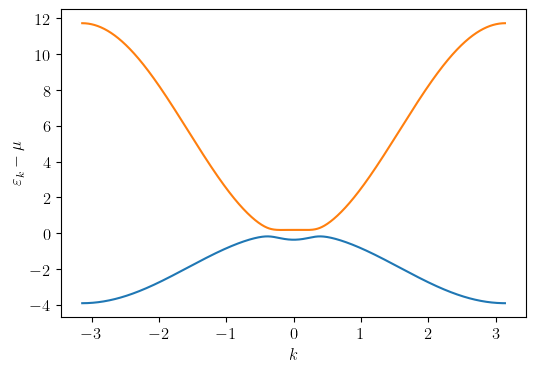

In [73]:
''' 1. find ground state '''

a = 1.
b = 0.5

t12 = 0.
delta = 0.

t = 1.
t_ = 3.
Vc = 0.
Vb = 2.

epsilon = 3.
epsilon_ = 3.

#gap = -3.
#epsilon = 0.5*(gap + 2*t_ + 2*t)
#epsilon_ = epsilon

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]

mu0 = 0.
include_hartree = True

Nk = 1500
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
gap = np.min(m.energije[1]) - np.max(m.energije[0])

plt.plot(m.K, m.energije[0] - m.mu)
plt.plot(m.K, m.energije[1] - m.mu)
plt.xlabel(r'$k$')
plt.ylabel(r'$\varepsilon_k - \mu$')
m.delta_b, m.delta_c, m.gap

m.delta_b, m.delta_c, m.gap

In [74]:
''' 2. go to small but finite temperature '''
beta0 = 40
scale = 1.008
betas = beta0/scale**np.arange(1,3)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
Gamma = 0.005

# Nomega, eps put to random small values because I am not interested in transport coefficients now
Nomega, eps = 3, 0.1
m.run2(betas, stops, Gamma, Nomega, eps)

started
39.682539682539684 9.172274051394425e-11 0.9999999584336223 -0.20667623015841816 -0.0
started evaluating at beta=39.36759889140841
39.36759889140841 9.20332698939319e-11 0.9999999213768229 -0.2066653440402887 -0.0


In [78]:
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, phys_parameters, include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)
omegas = np.logspace(-5, 0.5, 51)
Gamma = 0.01


chi_j_j, dchi_j_j, chi_rho_rho, chi_rho_j, chi_j_rho, chi_rho_rho_renorm = chi_jrho(m.K, tok_tilde, rhos_tilde, thetas, m.energije, m.mu, m.Ts[-1], omegas, Gamma)
chi_j_j2, dchi_j_j2, chi_rho_rho2, chi_rho_j2, chi_j_rho2, chi_rho_rho_renorm2 = chi_jrho2(m.K, tok_tilde, rhos_tilde, thetas, m.energije, m.mu, m.Ts[-1], omegas, Gamma)

(0.0, 2.5)

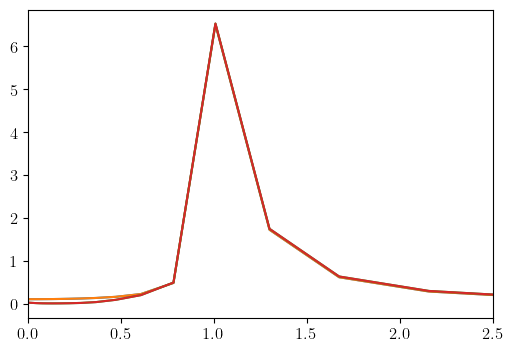

In [82]:
plt.plot(omegas / m.gap, sigma_f)
plt.plot(omegas / m.gap, sigma)
plt.plot(omegas / m.gap, sigma2_f)
plt.plot(omegas / m.gap, sigma2)

plt.xlim(0, 2.5)

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(np.float64(0.1098681147004598), np.complex128(0.027525985582559965+0j))

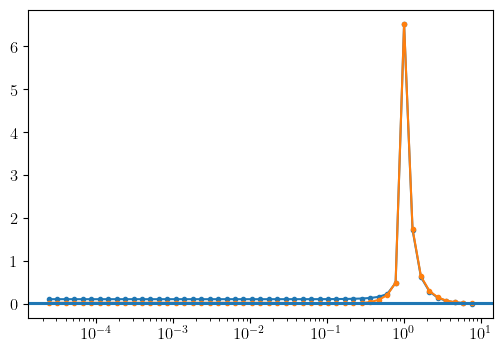

In [87]:
sigma_f = np.imag(chi_j_j) / omegas
sigma = np.imag(chi_j_j + dchi_j_j) / omegas
sigma2_f = np.imag(chi_j_j2) / omegas
sigma2 = np.imag(chi_j_j2 + dchi_j_j2) / omegas

epsilons = np.linspace(-1, 1, 501)
A = Spektralka(epsilons, m.mu, m.energije, Gamma)
phi = phi_Kubo(m.K, tok_tilde, tok_tilde, A, epsilons)
sigma_DC = np.sum(phi * (-fd_1(epsilons, m.Ts[-1]))) * (epsilons[1] - epsilons[0]) * np.pi
plt.plot(omegas / m.gap, sigma_f, '.-')
plt.plot(omegas / m.gap, sigma2_f, '.-')
plt.axhline(sigma_DC)
plt.xscale('log')

plt.axhline(0)

sigma_f[0], sigma_DC

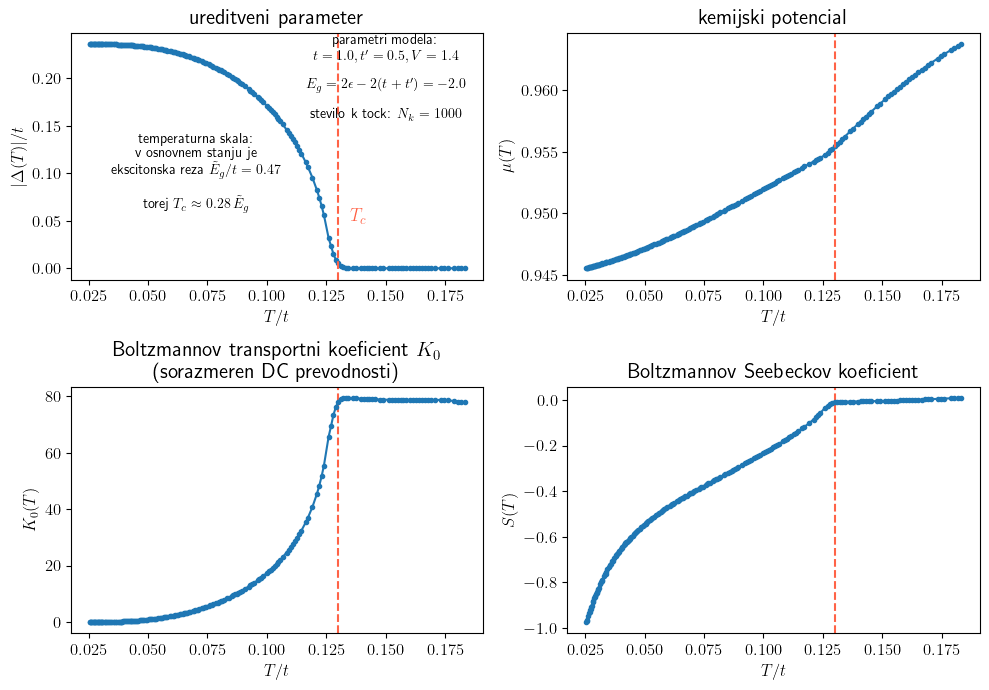

In [103]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,7))
ax[0,0].plot(m.Ts, np.abs(m.delta_bs), '.-')
ax[0,0].set_xlabel(r'$T/t$')
ax[0,0].set_ylabel(r'$|\Delta(T)| / t$')
ax[0,0].text(0.15, 0.2, r'parametri modela:' + '\n' + rf"$t={t}, t'={t_}, V={Vb}$" + '\n' + '\n' + \
                rf"$E_g=2\epsilon - 2(t+t')={gap}$" + '\n' + '\n' + \
        rf'stevilo k tock: $N_k={Nk}$', ha='center', va='center')

ax[0,0].text(0.07, 0.1, r'temperaturna skala:' + '\n' + r'v osnovnem stanju je' + '\n' + r'ekscitonska reza $\tilde{E}_g/t = 0.47 $' + '\n' + '\n' + \
        r'torej $T_c \approx 0.28 \, \tilde{E}_g$', ha='center', va='center')

ax[0,0].text(0.135, 0.05, r'$T_c$', fontsize=13, color='tomato')
ax[0,1].plot(m.Ts, m.mus, '.-')
for i in range(2):
    for j in range(2):
        ax[i,j].set_xlabel(r'$T/t$')
        ax[i,j].axvline(0.13, ls='dashed', color='tomato')

ax[0,1].set_ylabel(r'$\mu(T)$')

ax[1,0].plot(m.Ts, m.K0_b, '.-')
ax[1,1].plot(m.Ts, -np.array(m.K1_b) / np.array(m.K0_b) / np.array(m.Ts), '.-')

ax[1,0].set_ylabel(r'$K_0(T)$')
ax[1,1].set_ylabel(r'$S(T)$')

ax[0,0].set_title(r'ureditveni parameter')
ax[0,1].set_title(r'kemijski potencial')
ax[1,0].set_title(r'Boltzmannov transportni koeficient $K_0$' + '\n' + r'(sorazmeren DC prevodnosti)')
ax[1,1].set_title(r'Boltzmannov Seebeckov koeficient')

plt.tight_layout()
import os
os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('primer.pdf')

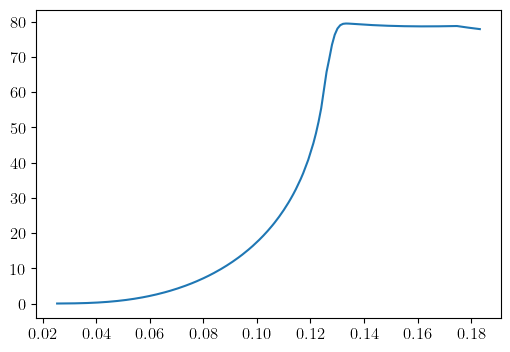

In [85]:
plt.plot(m.Ts, m.K0_b)

In [50]:
hamiltonian = h_k(m.K, m.hk0, m.rho, phys_parameters, 0., include_hartree)
energije, vecs, fs = diagonalize(hamiltonian, m.K, m.Ts[-1], m.mu)
m.delta_b

np.complex128(-3.838589217632207e-08+0j)

np.complex128(-3.838589217632207e-08+0j)

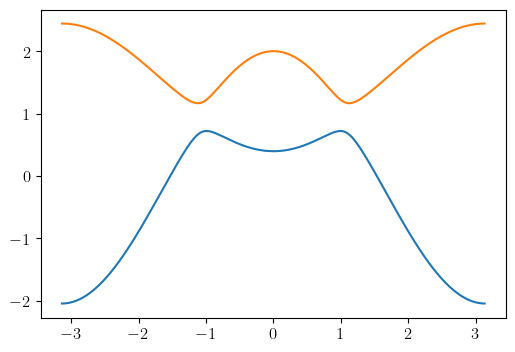

In [44]:
plt.plot(m.K, m.energije[0])
plt.plot(m.K, m.energije[1])
m.delta_b